In [2]:
# =========================================================
# Momentum Acceleration Research Starter Script
# =========================================================

import os
import datetime as dt

import polars as pl
from dotenv import load_dotenv
import sf_quant.data as sfd
import matplotlib.pyplot as plt
import polars as pl
import numpy as np


# -----------------------------
# 1. Load environment
# -----------------------------
load_dotenv("/home/nchasem/sf-quant-labs/.env")

# optional sanity check
print("ROOT:", os.getenv("ROOT"))
print("DATABASE:", os.getenv("DATABASE"))

ROOT: /home/nchasem
DATABASE: research


In [3]:
# -----------------------------
# 2. Parameters
# -----------------------------
START = dt.date(2000, 1, 1)
END   = dt.date(2025, 12, 31)

PRICE_FILTER = 5.0
SIGNAL_NAME = "accel_3v3"


# -----------------------------
# 3. Load daily asset data
# -----------------------------
# Important:
# In your current sf_quant setup, load_assets is daily.
# So we load daily, then roll it up to monthly ourselves.

data = sfd.load_assets(
    start=START,
    end=END,
    columns=[
        "date",
        "barrid",
        "ticker",
        "price",
        "return",
        "market_cap",
    ],
    in_universe=True,
)

print("Daily data shape:", data.shape)
print(data.head())


# -----------------------------
# 4. Clean and prepare daily data
# -----------------------------
data = (
    data
    .with_columns([
        pl.col("date").cast(pl.Date),
        pl.col("barrid").cast(pl.Utf8, strict=False),
        pl.col("ticker").cast(pl.Utf8, strict=False),
        pl.col("price").cast(pl.Float64, strict=False),
        pl.col("return").cast(pl.Float64, strict=False),
        pl.col("market_cap").cast(pl.Float64, strict=False),

        # convert percent return to decimal
        (pl.col("return") / 100.0).alias("ret_d"),

        # month bucket
        pl.col("date").dt.truncate("1mo").alias("month"),
    ])
    .sort(["barrid", "date"])
)

print("Prepared daily data shape:", data.shape)

Daily data shape: (19129651, 6)
shape: (5, 6)
┌────────────┬─────────┬────────┬───────┬─────────┬─────────────┐
│ date       ┆ barrid  ┆ ticker ┆ price ┆ return  ┆ market_cap  │
│ ---        ┆ ---     ┆ ---    ┆ ---   ┆ ---     ┆ ---         │
│ date       ┆ str     ┆ str    ┆ f64   ┆ f64     ┆ f64         │
╞════════════╪═════════╪════════╪═══════╪═════════╪═════════════╡
│ 2013-07-31 ┆ USA06Z1 ┆ MDXG   ┆ 6.26  ┆ -0.1595 ┆ 6.006157e8  │
│ 2013-08-01 ┆ USA06Z1 ┆ MDXG   ┆ 6.32  ┆ 0.9585  ┆ 6.0865392e8 │
│ 2013-08-02 ┆ USA06Z1 ┆ MDXG   ┆ 6.31  ┆ -0.1582 ┆ 6.0769086e8 │
│ 2013-08-05 ┆ USA06Z1 ┆ MDXG   ┆ 6.45  ┆ 2.2187  ┆ 6.211737e8  │
│ 2013-08-06 ┆ USA06Z1 ┆ MDXG   ┆ 6.29  ┆ -2.4806 ┆ 6.0576474e8 │
└────────────┴─────────┴────────┴───────┴─────────┴─────────────┘
Prepared daily data shape: (19129651, 8)


In [4]:
# -----------------------------
# 5. Aggregate daily -> monthly
# -----------------------------
# We create one row per stock per month:
# - month-end date
# - month-end price
# - month-end market cap
# - compounded monthly return
#
# Monthly return = product(1 + daily return) - 1
# implemented using logs for numerical stability

monthly = (
    data
    .group_by(["barrid", "month"])
    .agg([
        pl.col("date").max().alias("date"),
        pl.col("ticker").drop_nulls().last().alias("ticker"),
        pl.col("price").drop_nulls().last().alias("price"),
        pl.col("market_cap").drop_nulls().last().alias("market_cap"),

        (
            (pl.col("ret_d") + 1.0).log().sum().exp() - 1.0
        ).alias("ret_m"),
    ])
    .sort(["barrid", "date"])
)

print("Monthly panel shape:", monthly.shape)
print(monthly.head())

Monthly panel shape: (924286, 7)
shape: (5, 7)
┌─────────┬────────────┬────────────┬────────┬───────┬─────────────┬───────────┐
│ barrid  ┆ month      ┆ date       ┆ ticker ┆ price ┆ market_cap  ┆ ret_m     │
│ ---     ┆ ---        ┆ ---        ┆ ---    ┆ ---   ┆ ---         ┆ ---       │
│ str     ┆ date       ┆ date       ┆ str    ┆ f64   ┆ f64         ┆ f64       │
╞═════════╪════════════╪════════════╪════════╪═══════╪═════════════╪═══════════╡
│ USA06Z1 ┆ 2013-07-01 ┆ 2013-07-31 ┆ MDXG   ┆ 6.26  ┆ 6.006157e8  ┆ -0.001595 │
│ USA06Z1 ┆ 2013-08-01 ┆ 2013-08-30 ┆ MDXG   ┆ 6.17  ┆ 5.9463375e8 ┆ -0.014377 │
│ USA06Z1 ┆ 2013-09-01 ┆ 2013-09-30 ┆ MDXG   ┆ 4.17  ┆ 4.0188375e8 ┆ -0.324148 │
│ USA06Z1 ┆ 2013-10-01 ┆ 2013-10-31 ┆ MDXG   ┆ 5.3   ┆ 5.174708e8  ┆ 0.270982  │
│ USA06Z1 ┆ 2013-11-01 ┆ 2013-11-29 ┆ MDXG   ┆ 6.3   ┆ 6.071625e8  ┆ 0.188682  │
└─────────┴────────────┴────────────┴────────┴───────┴─────────────┴───────────┘


In [5]:
# -----------------------------
# 6. Build lagged monthly returns
# -----------------------------
monthly = (
    monthly
    .with_columns([
        pl.col("ret_m").shift(1).over("barrid").alias("ret_l1"),
        pl.col("ret_m").shift(2).over("barrid").alias("ret_l2"),
        pl.col("ret_m").shift(3).over("barrid").alias("ret_l3"),
        pl.col("ret_m").shift(4).over("barrid").alias("ret_l4"),
        pl.col("ret_m").shift(5).over("barrid").alias("ret_l5"),
        pl.col("ret_m").shift(6).over("barrid").alias("ret_l6"),
        pl.col("ret_m").shift(7).over("barrid").alias("ret_l7"),
    ])
)

print("After lags shape:", monthly.shape)

After lags shape: (924286, 14)


In [6]:
# -----------------------------
# 7. Compute 3m recent and 3m old returns
# -----------------------------
# recent 3m: t-1, t-2, t-3
# old 3m:    t-4, t-5, t-6

monthly = (
    monthly
    .with_columns([
        (
            (1.0 + pl.col("ret_l1")) *
            (1.0 + pl.col("ret_l2")) *
            (1.0 + pl.col("ret_l3")) - 1.0
        ).alias("ret_recent_3m"),

        (
            (1.0 + pl.col("ret_l4")) *
            (1.0 + pl.col("ret_l5")) *
            (1.0 + pl.col("ret_l6")) - 1.0
        ).alias("ret_old_3m"),
    ])
    .with_columns([
        (pl.col("ret_recent_3m") - pl.col("ret_old_3m")).alias(SIGNAL_NAME)
    ])
)

print("After signal shape:", monthly.shape)


# -----------------------------
# 8. Forward 1m return
# -----------------------------
monthly = monthly.with_columns([
    pl.col("ret_m").shift(-1).over("barrid").alias("ret_fwd_1m")
])

print("After forward return shape:", monthly.shape)

After signal shape: (924286, 17)
After forward return shape: (924286, 18)


In [7]:
# -----------------------------
# 9. Lagged price filter
# -----------------------------
# Use lagged month-end price so the formation month only uses known info

monthly = monthly.with_columns([
    pl.col("price").shift(1).over("barrid").alias("price_lag1")
])

filtered = (
    monthly
    .filter(
        pl.col("price_lag1") > PRICE_FILTER,
        pl.col(SIGNAL_NAME).is_not_null(),
        pl.col("ret_fwd_1m").is_not_null(),
    )
    .sort(["date", "barrid"])
)

print("Filtered monthly panel shape:", filtered.shape)
print(filtered.select([
    "date",
    "barrid",
    "ticker",
    "price",
    "price_lag1",
    "ret_recent_3m",
    "ret_old_3m",
    SIGNAL_NAME,
    "ret_fwd_1m",
]).head(20))

Filtered monthly panel shape: (794714, 19)
shape: (20, 9)
┌────────────┬─────────┬────────┬─────────┬───┬──────────────┬────────────┬───────────┬────────────┐
│ date       ┆ barrid  ┆ ticker ┆ price   ┆ … ┆ ret_recent_3 ┆ ret_old_3m ┆ accel_3v3 ┆ ret_fwd_1m │
│ ---        ┆ ---     ┆ ---    ┆ ---     ┆   ┆ m            ┆ ---        ┆ ---       ┆ ---        │
│ date       ┆ str     ┆ str    ┆ f64     ┆   ┆ ---          ┆ f64        ┆ f64       ┆ f64        │
│            ┆         ┆        ┆         ┆   ┆ f64          ┆            ┆           ┆            │
╞════════════╪═════════╪════════╪═════════╪═══╪══════════════╪════════════╪═══════════╪════════════╡
│ 2000-07-31 ┆ USA11I1 ┆ EBAY   ┆ 50.0    ┆ … ┆ -0.382812    ┆ 0.405891   ┆ -0.788703 ┆ 0.240001   │
│ 2000-07-31 ┆ USA11Q1 ┆ LWIN   ┆ 63.375  ┆ … ┆ -0.523751    ┆ 0.257167   ┆ -0.780918 ┆ 0.252467   │
│ 2000-07-31 ┆ USA12J1 ┆ PZL    ┆ 12.5    ┆ … ┆ 0.1755       ┆ 0.046034   ┆ 0.129466  ┆ 0.009632   │
│ 2000-07-31 ┆ USA14R1 ┆ HLTH   ┆

In [8]:
# -----------------------------
# 10. Cross-sectional z-score by date
# -----------------------------
scored = (
    filtered
    .with_columns([
        (
            (pl.col(SIGNAL_NAME) - pl.col(SIGNAL_NAME).mean().over("date")) /
            pl.col(SIGNAL_NAME).std().over("date")
        ).alias("score")
    ])
    .sort(["date", "barrid"])
)

print("Scored panel shape:", scored.shape)
print(scored.select([
    "date",
    "barrid",
    "ticker",
    SIGNAL_NAME,
    "score",
    "ret_fwd_1m",
]).head(20))

# -----------------------------
# 11. Deciles by date
# -----------------------------
scored = (
    scored
    .filter(pl.col("score").is_not_null())
    .with_columns(
        pl.col("score")
        .rank("ordinal")
        .over("date")
        .alias("rank")
    )
    .with_columns(
        (
            ((pl.col("rank") - 1) * 10 / pl.len().over("date"))
            .floor() + 1
        ).clip(upper_bound=10).alias("decile")
    )
)

print(scored.select(["date","barrid","score","decile"]).head(20))

Scored panel shape: (794714, 20)
shape: (20, 6)
┌────────────┬─────────┬────────┬───────────┬───────────┬────────────┐
│ date       ┆ barrid  ┆ ticker ┆ accel_3v3 ┆ score     ┆ ret_fwd_1m │
│ ---        ┆ ---     ┆ ---    ┆ ---       ┆ ---       ┆ ---        │
│ date       ┆ str     ┆ str    ┆ f64       ┆ f64       ┆ f64        │
╞════════════╪═════════╪════════╪═══════════╪═══════════╪════════════╡
│ 2000-07-31 ┆ USA11I1 ┆ EBAY   ┆ -0.788703 ┆ -1.513382 ┆ 0.240001   │
│ 2000-07-31 ┆ USA11Q1 ┆ LWIN   ┆ -0.780918 ┆ -1.496837 ┆ 0.252467   │
│ 2000-07-31 ┆ USA12J1 ┆ PZL    ┆ 0.129466  ┆ 0.437897  ┆ 0.009632   │
│ 2000-07-31 ┆ USA14R1 ┆ HLTH   ┆ 0.030688  ┆ 0.227976  ┆ 0.323943   │
│ 2000-07-31 ┆ USA16C1 ┆ CLPA   ┆ -3.032576 ┆ -6.282026 ┆ 0.286058   │
│ …          ┆ …       ┆ …      ┆ …         ┆ …         ┆ …          │
│ 2000-07-31 ┆ USA19J1 ┆ INF    ┆ 0.230841  ┆ 0.653336  ┆ 0.07447    │
│ 2000-07-31 ┆ USA19W1 ┆ HIFN   ┆ -0.996996 ┆ -1.956044 ┆ 0.310968   │
│ 2000-07-31 ┆ USA19Y1 ┆ INSP

In [9]:
# -----------------------------
# 12. Decile returns
# -----------------------------

decile_returns = (
    scored
    .group_by(["date", "decile"])
    .agg(
        pl.col("ret_fwd_1m").mean().alias("ret")
    )
    .sort(["date", "decile"])
)

print(decile_returns.head(20))

mean_deciles = (
    decile_returns
    .group_by("decile")
    .agg(pl.col("ret").mean())
    .sort("decile")
)

print(mean_deciles)

shape: (20, 3)
┌────────────┬────────┬───────────┐
│ date       ┆ decile ┆ ret       │
│ ---        ┆ ---    ┆ ---       │
│ date       ┆ f64    ┆ f64       │
╞════════════╪════════╪═══════════╡
│ 2000-07-31 ┆ 1.0    ┆ 0.133241  │
│ 2000-07-31 ┆ 2.0    ┆ 0.119391  │
│ 2000-07-31 ┆ 3.0    ┆ 0.074947  │
│ 2000-07-31 ┆ 4.0    ┆ 0.062444  │
│ 2000-07-31 ┆ 5.0    ┆ 0.061978  │
│ …          ┆ …      ┆ …         │
│ 2000-08-31 ┆ 6.0    ┆ 0.008164  │
│ 2000-08-31 ┆ 7.0    ┆ -0.001465 │
│ 2000-08-31 ┆ 8.0    ┆ -0.009768 │
│ 2000-08-31 ┆ 9.0    ┆ -0.021707 │
│ 2000-08-31 ┆ 10.0   ┆ -0.040164 │
└────────────┴────────┴───────────┘
shape: (10, 2)
┌────────┬──────────┐
│ decile ┆ ret      │
│ ---    ┆ ---      │
│ f64    ┆ f64      │
╞════════╪══════════╡
│ 1.0    ┆ 0.007716 │
│ 2.0    ┆ 0.008947 │
│ 3.0    ┆ 0.009062 │
│ 4.0    ┆ 0.008464 │
│ 5.0    ┆ 0.009252 │
│ 6.0    ┆ 0.007746 │
│ 7.0    ┆ 0.007667 │
│ 8.0    ┆ 0.008709 │
│ 9.0    ┆ 0.005911 │
│ 10.0   ┆ 0.006136 │
└────────┴──────────┘


In [10]:
# -----------------------------
# 13. Long-short returns
# -----------------------------

ls_returns = (
    decile_returns
    .pivot(index="date", columns="decile", values="ret")
    .with_columns(
        (pl.col("10.0") - pl.col("1.0")).alias("ls")
    )
    .select(["date", "ls"])
    .sort("date")
)

print(ls_returns.head())

shape: (5, 2)
┌────────────┬───────────┐
│ date       ┆ ls        │
│ ---        ┆ ---       │
│ date       ┆ f64       │
╞════════════╪═══════════╡
│ 2000-07-31 ┆ -0.065658 │
│ 2000-08-31 ┆ 0.049293  │
│ 2000-09-29 ┆ -0.062243 │
│ 2000-10-31 ┆ -0.038254 │
│ 2000-11-30 ┆ -0.004778 │
└────────────┴───────────┘


/tmp/ipykernel_1226972/2167265899.py:7: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="date", columns="decile", values="ret")


In [11]:
# -----------------------------
# 14. Long-short returns
# -----------------------------
mean_ls = ls_returns.select(pl.col("ls").mean()).item()
std_ls  = ls_returns.select(pl.col("ls").std()).item()

print("Mean LS Return:", mean_ls)
print("Std LS:", std_ls)
print("Sharpe (annualized):", mean_ls / std_ls * (12 ** 0.5))

Mean LS Return: -0.0021605786945537394
Std LS: 0.04034824085674772
Sharpe (annualized): -0.18549666569129122


In [12]:
# This signal alone is not tradable, let's double sort momentum and acceleration. 
scored = scored.with_columns([
    (
        (1 + pl.col("ret_l2")) *
        (1 + pl.col("ret_l3")) *
        (1 + pl.col("ret_l4")) *
        (1 + pl.col("ret_l5")) *
        (1 + pl.col("ret_l6")) *
        (1 + pl.col("ret_l7")) -
        1
    ).alias("mom_6m")
])

# rank both
scored = scored.with_columns([
    pl.col("mom_6m").rank("ordinal").over("date").alias("mom_rank"),
    pl.col("accel_3v3").rank("ordinal").over("date").alias("accel_rank"),
])

# create buckets for both
scored = scored.with_columns([
    (pl.col("mom_rank") / pl.col("mom_rank").max().over("date") * 5).ceil().alias("mom_q"),
    (pl.col("accel_rank") / pl.col("accel_rank").max().over("date") * 5).ceil().alias("accel_q"),
])

# test only high momentum
high_mom = scored.filter(pl.col("mom_q") >= 4)

# Sanity check
print(scored.select([
    "date", "mom_q", "accel_q"
]).drop_nulls().head(20))

shape: (20, 3)
┌────────────┬───────┬─────────┐
│ date       ┆ mom_q ┆ accel_q │
│ ---        ┆ ---   ┆ ---     │
│ date       ┆ f64   ┆ f64     │
╞════════════╪═══════╪═════════╡
│ 2000-08-31 ┆ 2.0   ┆ 1.0     │
│ 2000-08-31 ┆ 1.0   ┆ 5.0     │
│ 2000-08-31 ┆ 4.0   ┆ 4.0     │
│ 2000-08-31 ┆ 1.0   ┆ 5.0     │
│ 2000-08-31 ┆ 5.0   ┆ 4.0     │
│ …          ┆ …     ┆ …       │
│ 2000-08-31 ┆ 3.0   ┆ 3.0     │
│ 2000-08-31 ┆ 4.0   ┆ 5.0     │
│ 2000-08-31 ┆ 3.0   ┆ 1.0     │
│ 2000-08-31 ┆ 3.0   ┆ 2.0     │
│ 2000-08-31 ┆ 2.0   ┆ 4.0     │
└────────────┴───────┴─────────┘


In [13]:
# High momentum only
high_mom = scored.filter(pl.col("mom_q") >= 4)

accel_test = (
    high_mom
    .with_columns(
        pl.col("accel_3v3")
        .rank("ordinal")
        .over("date")
        .alias("rank")
    )
    .with_columns(
        (
            ((pl.col("rank") - 1) * 10 / pl.len().over("date"))
            .floor() + 1
        ).clip(upper_bound=10).alias("decile")
    )
)

# decile returns for high momentum stocks by accel deciles
decile_returns_accel = (
    accel_test
    .group_by(["date", "decile"])
    .agg(pl.col("ret_fwd_1m").mean().alias("ret"))
    .sort(["date", "decile"])
)

# mean deciles
mean_deciles_accel = (
    decile_returns_accel
    .group_by("decile")
    .agg(pl.col("ret").mean())
    .sort("decile")
)

print(mean_deciles_accel)

shape: (10, 2)
┌────────┬──────────┐
│ decile ┆ ret      │
│ ---    ┆ ---      │
│ f64    ┆ f64      │
╞════════╪══════════╡
│ 1.0    ┆ 0.008965 │
│ 2.0    ┆ 0.010352 │
│ 3.0    ┆ 0.008383 │
│ 4.0    ┆ 0.009801 │
│ 5.0    ┆ 0.008957 │
│ 6.0    ┆ 0.008133 │
│ 7.0    ┆ 0.008104 │
│ 8.0    ┆ 0.007716 │
│ 9.0    ┆ 0.007456 │
│ 10.0   ┆ 0.008189 │
└────────┴──────────┘


In [14]:
# long short and performance
ls_accel = (
    decile_returns_accel
    .pivot(index="date", columns="decile", values="ret")
    .with_columns(
        (pl.col("10.0") - pl.col("1.0")).alias("ls")
    )
    .select(["date", "ls"])
    .sort("date")
)

mean_ls = ls_accel.select(pl.col("ls").mean()).item()
std_ls  = ls_accel.select(pl.col("ls").std()).item()

print("Mean LS:", mean_ls)
print("Sharpe:", mean_ls / std_ls * (12 ** 0.5))

Mean LS: -0.0016819550229145179
Sharpe: -0.12536574060544053


/tmp/ipykernel_1226972/1251786870.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="date", columns="decile", values="ret")


In [15]:
# =========================================================
# Specific Return Acceleration Research Script
# =========================================================

import os
import datetime as dt

import polars as pl
from dotenv import load_dotenv
import sf_quant.data as sfd


# -----------------------------
# 1. Load environment
# -----------------------------
load_dotenv("/home/nchasem/sf-quant-labs/.env")

print("ROOT:", os.getenv("ROOT"))
print("DATABASE:", os.getenv("DATABASE"))


# -----------------------------
# 2. Parameters
# -----------------------------
START = dt.date(2000, 1, 1)
END   = dt.date(2025, 12, 31)

PRICE_FILTER = 5.0
SIGNAL_NAME = "spec_accel_3v3"


# -----------------------------
# 3. Load daily asset data
# -----------------------------
data = sfd.load_assets(
    start=START,
    end=END,
    columns=[
        "date",
        "barrid",
        "ticker",
        "price",
        "return",
        "specific_return",
        "market_cap",
    ],
    in_universe=True,
)

print("Daily data shape:", data.shape)
print(data.head())


# -----------------------------
# 4. Clean and prepare daily data
# -----------------------------
data = (
    data
    .with_columns([
        pl.col("date").cast(pl.Date),
        pl.col("barrid").cast(pl.Utf8, strict=False),
        pl.col("ticker").cast(pl.Utf8, strict=False),
        pl.col("price").cast(pl.Float64, strict=False),
        pl.col("return").cast(pl.Float64, strict=False),
        pl.col("specific_return").cast(pl.Float64, strict=False),
        pl.col("market_cap").cast(pl.Float64, strict=False),

        # convert percent returns to decimal
        (pl.col("return") / 100.0).alias("ret_d"),
        (pl.col("specific_return") / 100.0).alias("spec_ret_d"),

        # month bucket
        pl.col("date").dt.truncate("1mo").alias("month"),
    ])
    .sort(["barrid", "date"])
)

print("Prepared daily data shape:", data.shape)


# -----------------------------
# 5. Aggregate daily -> monthly
# -----------------------------
monthly = (
    data
    .group_by(["barrid", "month"])
    .agg([
        pl.col("date").max().alias("date"),
        pl.col("ticker").drop_nulls().last().alias("ticker"),
        pl.col("price").drop_nulls().last().alias("price"),
        pl.col("market_cap").drop_nulls().last().alias("market_cap"),

        # raw monthly return
        (
            (pl.col("ret_d") + 1.0).log().sum().exp() - 1.0
        ).alias("ret_m"),

        # monthly specific return
        (
            (pl.col("spec_ret_d") + 1.0).log().sum().exp() - 1.0
        ).alias("spec_ret_m"),
    ])
    .sort(["barrid", "date"])
)

print("Monthly panel shape:", monthly.shape)
print(monthly.head())


# -----------------------------
# 6. Build lagged monthly specific returns
# -----------------------------
monthly = (
    monthly
    .with_columns([
        pl.col("spec_ret_m").shift(1).over("barrid").alias("spec_ret_l1"),
        pl.col("spec_ret_m").shift(2).over("barrid").alias("spec_ret_l2"),
        pl.col("spec_ret_m").shift(3).over("barrid").alias("spec_ret_l3"),
        pl.col("spec_ret_m").shift(4).over("barrid").alias("spec_ret_l4"),
        pl.col("spec_ret_m").shift(5).over("barrid").alias("spec_ret_l5"),
        pl.col("spec_ret_m").shift(6).over("barrid").alias("spec_ret_l6"),
        pl.col("spec_ret_m").shift(7).over("barrid").alias("spec_ret_l7"),
    ])
)

print("After lagged specific returns shape:", monthly.shape)


# -----------------------------
# 7. Compute 3m recent and 3m old specific returns
# -----------------------------
monthly = (
    monthly
    .with_columns([
        (
            (1.0 + pl.col("spec_ret_l1")) *
            (1.0 + pl.col("spec_ret_l2")) *
            (1.0 + pl.col("spec_ret_l3")) - 1.0
        ).alias("spec_ret_recent_3m"),

        (
            (1.0 + pl.col("spec_ret_l4")) *
            (1.0 + pl.col("spec_ret_l5")) *
            (1.0 + pl.col("spec_ret_l6")) - 1.0
        ).alias("spec_ret_old_3m"),
    ])
    .with_columns([
        (
            pl.col("spec_ret_recent_3m") - pl.col("spec_ret_old_3m")
        ).alias(SIGNAL_NAME)
    ])
)

print("After specific acceleration signal shape:", monthly.shape)


# -----------------------------
# 8. Forward 1m raw return
# -----------------------------
# We still predict actual next-month returns, not next-month specific return
monthly = monthly.with_columns([
    pl.col("ret_m").shift(-1).over("barrid").alias("ret_fwd_1m")
])

print("After forward return shape:", monthly.shape)


# -----------------------------
# 9. Lagged price filter
# -----------------------------
monthly = monthly.with_columns([
    pl.col("price").shift(1).over("barrid").alias("price_lag1")
])

filtered = (
    monthly
    .filter(
        pl.col("price_lag1") > PRICE_FILTER,
        pl.col(SIGNAL_NAME).is_not_null(),
        pl.col("ret_fwd_1m").is_not_null(),
    )
    .sort(["date", "barrid"])
)

print("Filtered monthly panel shape:", filtered.shape)
print(filtered.select([
    "date",
    "barrid",
    "ticker",
    "price",
    "price_lag1",
    "spec_ret_recent_3m",
    "spec_ret_old_3m",
    SIGNAL_NAME,
    "ret_fwd_1m",
]).head(20))


# -----------------------------
# 10. Cross-sectional z-score by date
# -----------------------------
scored = (
    filtered
    .with_columns([
        (
            (pl.col(SIGNAL_NAME) - pl.col(SIGNAL_NAME).mean().over("date")) /
            pl.col(SIGNAL_NAME).std().over("date")
        ).alias("score")
    ])
    .filter(pl.col("score").is_not_null())
    .sort(["date", "barrid"])
)

print("Scored panel shape:", scored.shape)
print(scored.select([
    "date",
    "barrid",
    "ticker",
    SIGNAL_NAME,
    "score",
    "ret_fwd_1m",
]).head(20))


# -----------------------------
# 11. Deciles by date
# -----------------------------
scored = (
    scored
    .with_columns(
        pl.col("score")
        .rank("ordinal")
        .over("date")
        .alias("rank")
    )
    .with_columns(
        (
            ((pl.col("rank") - 1) * 10 / pl.len().over("date"))
            .floor() + 1
        ).clip(upper_bound=10).alias("decile")
    )
)

print(scored.select(["date", "barrid", "score", "decile"]).head(20))


# -----------------------------
# 12. Decile returns
# -----------------------------
decile_returns = (
    scored
    .group_by(["date", "decile"])
    .agg(
        pl.col("ret_fwd_1m").mean().alias("ret")
    )
    .sort(["date", "decile"])
)

print(decile_returns.head(20))


# -----------------------------
# 13. Mean return by decile
# -----------------------------
mean_deciles = (
    decile_returns
    .group_by("decile")
    .agg(pl.col("ret").mean())
    .sort("decile")
)

print(mean_deciles)


# -----------------------------
# 14. Long-short returns
# -----------------------------
ls_returns = (
    decile_returns
    .pivot(index="date", columns="decile", values="ret")
    .with_columns(
        (pl.col("10.0") - pl.col("1.0")).alias("ls")
    )
    .select(["date", "ls"])
    .sort("date")
)

print(ls_returns.head())


# -----------------------------
# 15. Mean LS return + Sharpe
# -----------------------------
mean_ls = ls_returns.select(pl.col("ls").mean()).item()
std_ls  = ls_returns.select(pl.col("ls").std()).item()

print("Mean LS Return:", mean_ls)
print("Std LS:", std_ls)
print("Sharpe (annualized):", mean_ls / std_ls * (12 ** 0.5))


# -----------------------------
# 16. Information Coefficient
# -----------------------------
ic = (
    scored
    .group_by("date")
    .agg(
        pl.corr("score", "ret_fwd_1m").alias("ic")
    )
)

print("Mean IC:", ic.select(pl.col("ic").mean()).item())
print("Std IC:", ic.select(pl.col("ic").std()).item())

ROOT: /home/nchasem
DATABASE: research


Daily data shape: (19129651, 7)
shape: (5, 7)
┌────────────┬─────────┬────────┬───────┬─────────┬─────────────────┬─────────────┐
│ date       ┆ barrid  ┆ ticker ┆ price ┆ return  ┆ specific_return ┆ market_cap  │
│ ---        ┆ ---     ┆ ---    ┆ ---   ┆ ---     ┆ ---             ┆ ---         │
│ date       ┆ str     ┆ str    ┆ f64   ┆ f64     ┆ f64             ┆ f64         │
╞════════════╪═════════╪════════╪═══════╪═════════╪═════════════════╪═════════════╡
│ 2013-07-31 ┆ USA06Z1 ┆ MDXG   ┆ 6.26  ┆ -0.1595 ┆ -0.788          ┆ 6.006157e8  │
│ 2013-08-01 ┆ USA06Z1 ┆ MDXG   ┆ 6.32  ┆ 0.9585  ┆ 0.365           ┆ 6.0865392e8 │
│ 2013-08-02 ┆ USA06Z1 ┆ MDXG   ┆ 6.31  ┆ -0.1582 ┆ -0.731          ┆ 6.0769086e8 │
│ 2013-08-05 ┆ USA06Z1 ┆ MDXG   ┆ 6.45  ┆ 2.2187  ┆ 1.936           ┆ 6.211737e8  │
│ 2013-08-06 ┆ USA06Z1 ┆ MDXG   ┆ 6.29  ┆ -2.4806 ┆ -0.528          ┆ 6.0576474e8 │
└────────────┴─────────┴────────┴───────┴─────────┴─────────────────┴─────────────┘
Prepared daily data shape: (19

/tmp/ipykernel_1226972/2925272988.py:280: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="date", columns="decile", values="ret")


In [17]:
# Plot function
def plot_cum_returns(ls_df, title):
    df = (
        ls_df
        .with_columns(
            (1 + pl.col("ls")).log().alias("log_ret")
        )
        .with_columns(
            pl.col("log_ret").cum_sum().alias("cum_log_ret")
        )
    )

    plt.figure()
    plt.plot(df["date"], df["cum_log_ret"])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.grid(True)
    plt.show()

# Decile table with sharpe
def decile_table_with_sharpe(decile_returns):
    # mean return per decile
    mean_returns = (
        decile_returns
        .group_by("decile")
        .agg(pl.col("ret").mean().alias("mean_ret"))
    )

    # std per decile
    std_returns = (
        decile_returns
        .group_by("decile")
        .agg(pl.col("ret").std().alias("std_ret"))
    )

    table = mean_returns.join(std_returns, on="decile")

    table = table.with_columns(
        (pl.col("mean_ret") / pl.col("std_ret") * np.sqrt(12)).alias("sharpe")
    ).sort("decile")

    return table

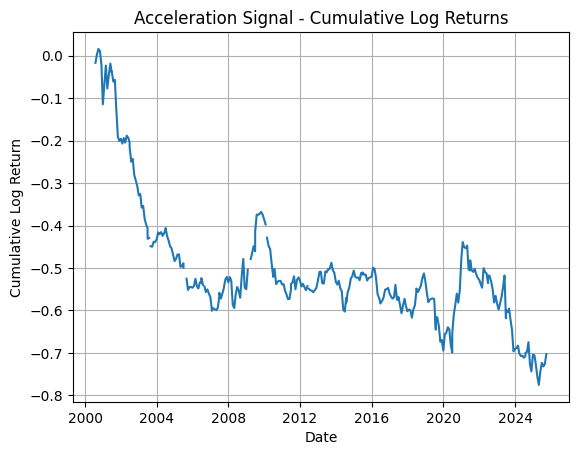

shape: (10, 4)
┌────────┬──────────┬──────────┬──────────┐
│ decile ┆ mean_ret ┆ std_ret  ┆ sharpe   │
│ ---    ┆ ---      ┆ ---      ┆ ---      │
│ f64    ┆ f64      ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╪══════════╡
│ 1.0    ┆ 0.006902 ┆ 0.070772 ┆ 0.337854 │
│ 2.0    ┆ 0.008627 ┆ 0.058393 ┆ 0.511793 │
│ 3.0    ┆ 0.009043 ┆ 0.054196 ┆ 0.57803  │
│ 4.0    ┆ 0.008867 ┆ 0.050923 ┆ 0.603192 │
│ 5.0    ┆ 0.009129 ┆ 0.049719 ┆ 0.636068 │
│ 6.0    ┆ 0.008326 ┆ 0.049995 ┆ 0.576909 │
│ 7.0    ┆ 0.008442 ┆ 0.04968  ┆ 0.588619 │
│ 8.0    ┆ 0.007711 ┆ 0.053219 ┆ 0.501903 │
│ 9.0    ┆ 0.006971 ┆ 0.056708 ┆ 0.425851 │
│ 10.0   ┆ 0.005575 ┆ 0.06606  ┆ 0.29234  │
└────────┴──────────┴──────────┴──────────┘


In [18]:
# Raw exceleration
plot_cum_returns(ls_returns, "Acceleration Signal - Cumulative Log Returns")
table_accel = decile_table_with_sharpe(decile_returns)
print(table_accel)

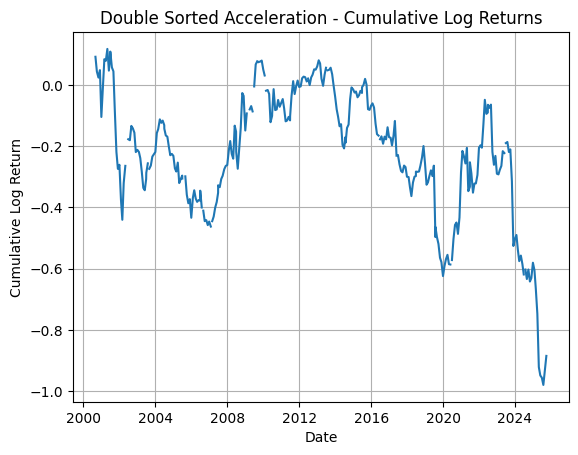

shape: (10, 4)
┌────────┬──────────┬──────────┬──────────┐
│ decile ┆ mean_ret ┆ std_ret  ┆ sharpe   │
│ ---    ┆ ---      ┆ ---      ┆ ---      │
│ f64    ┆ f64      ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╪══════════╡
│ 1.0    ┆ 0.008965 ┆ 0.07242  ┆ 0.428804 │
│ 2.0    ┆ 0.010352 ┆ 0.059514 ┆ 0.602551 │
│ 3.0    ┆ 0.008383 ┆ 0.054333 ┆ 0.534505 │
│ 4.0    ┆ 0.009801 ┆ 0.051485 ┆ 0.659421 │
│ 5.0    ┆ 0.008957 ┆ 0.047591 ┆ 0.651962 │
│ 6.0    ┆ 0.008133 ┆ 0.048655 ┆ 0.579063 │
│ 7.0    ┆ 0.008104 ┆ 0.046954 ┆ 0.597896 │
│ 8.0    ┆ 0.007716 ┆ 0.050198 ┆ 0.53247  │
│ 9.0    ┆ 0.007456 ┆ 0.050721 ┆ 0.509255 │
│ 10.0   ┆ 0.008189 ┆ 0.062457 ┆ 0.454194 │
└────────┴──────────┴──────────┴──────────┘


In [19]:
# Double sort
plot_cum_returns(ls_accel, "Double Sorted Acceleration - Cumulative Log Returns")
table_double = decile_table_with_sharpe(decile_returns_accel)
print(table_double)

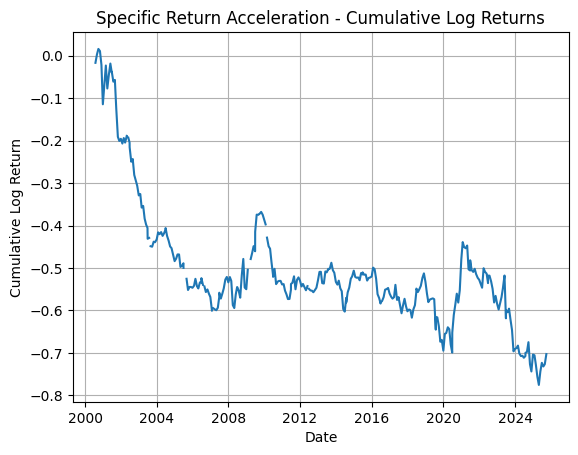

shape: (10, 4)
┌────────┬──────────┬──────────┬──────────┐
│ decile ┆ mean_ret ┆ std_ret  ┆ sharpe   │
│ ---    ┆ ---      ┆ ---      ┆ ---      │
│ f64    ┆ f64      ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╪══════════╡
│ 1.0    ┆ 0.006902 ┆ 0.070772 ┆ 0.337854 │
│ 2.0    ┆ 0.008627 ┆ 0.058393 ┆ 0.511793 │
│ 3.0    ┆ 0.009043 ┆ 0.054196 ┆ 0.57803  │
│ 4.0    ┆ 0.008867 ┆ 0.050923 ┆ 0.603192 │
│ 5.0    ┆ 0.009129 ┆ 0.049719 ┆ 0.636068 │
│ 6.0    ┆ 0.008326 ┆ 0.049995 ┆ 0.576909 │
│ 7.0    ┆ 0.008442 ┆ 0.04968  ┆ 0.588619 │
│ 8.0    ┆ 0.007711 ┆ 0.053219 ┆ 0.501903 │
│ 9.0    ┆ 0.006971 ┆ 0.056708 ┆ 0.425851 │
│ 10.0   ┆ 0.005575 ┆ 0.06606  ┆ 0.29234  │
└────────┴──────────┴──────────┴──────────┘


In [20]:
# Specific return acceleration
plot_cum_returns(ls_returns, "Specific Return Acceleration - Cumulative Log Returns")
table_spec = decile_table_with_sharpe(decile_returns)
print(table_spec)

In [25]:
def plot_deciles_and_spread(decile_returns, title):

    # 1. cumulative log returns by decile
    df = (
        decile_returns
        .with_columns(
            (1 + pl.col("ret")).log().alias("log_ret")
        )
        .with_columns(
            pl.col("log_ret").cum_sum().over("decile").alias("cum_log_ret")
        )
    )

    # 2. pivot wide
    wide = df.pivot(index="date", columns="decile", values="cum_log_ret").sort("date")

    # 3. spread = decile 10 - decile 1
    wide = wide.with_columns(
        (pl.col("10.0") - pl.col("1.0")).alias("spread")
    )

    pdf = wide.to_pandas()

    # 4. plot
    plt.figure(figsize=(10, 6))

    for d in range(1, 11):
        plt.plot(pdf["date"], pdf[f"{float(d):.1f}"], alpha=0.4, label=f"Decile {d}")

    plt.plot(pdf["date"], pdf["spread"], linewidth=3, label="Spread (10-1)")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.legend(ncol=2)
    plt.grid(True)
    plt.show()

/tmp/ipykernel_1226972/4210587198.py:15: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  wide = df.pivot(index="date", columns="decile", values="cum_log_ret").sort("date")


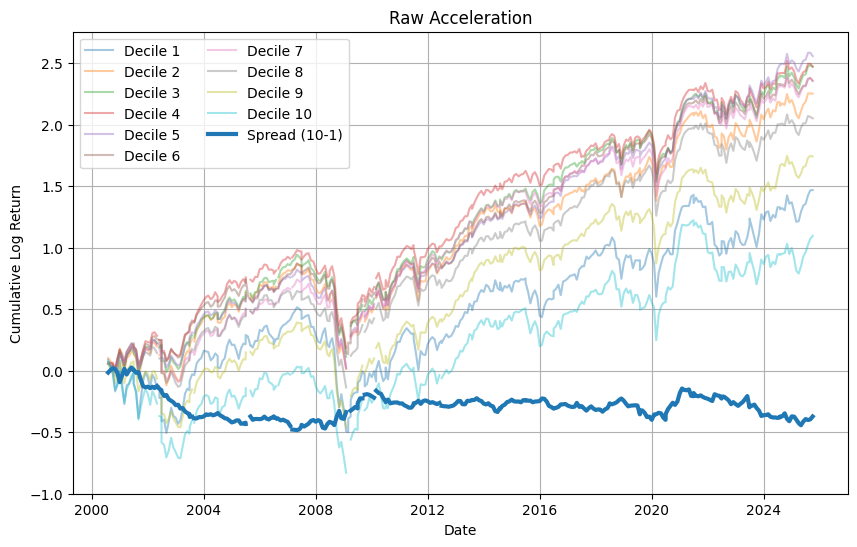

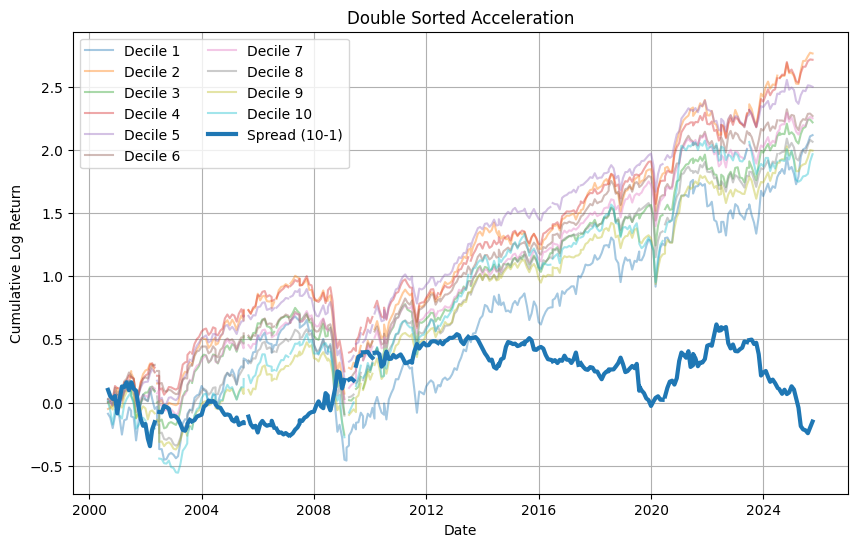

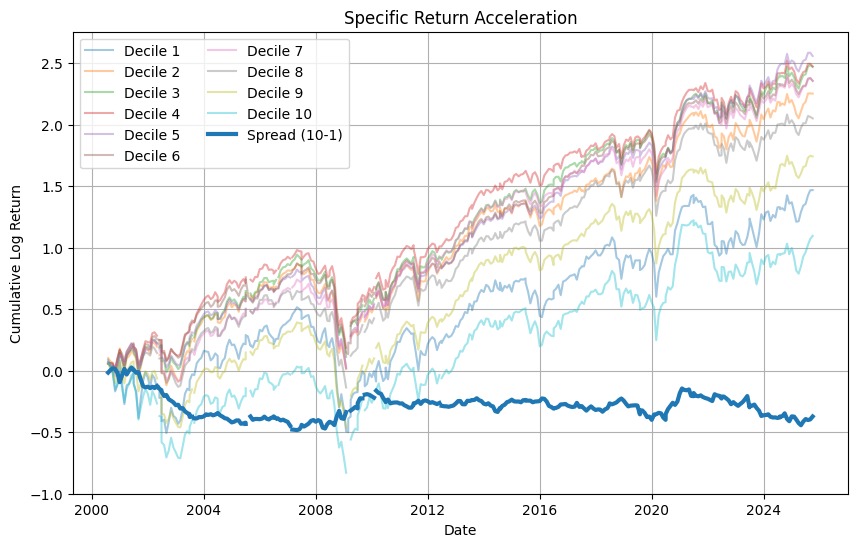

In [29]:
plot_deciles_and_spread(decile_returns, "Raw Acceleration")

plot_deciles_and_spread(decile_returns_accel, "Double Sorted Acceleration")

plot_deciles_and_spread(decile_returns, "Specific Return Acceleration")

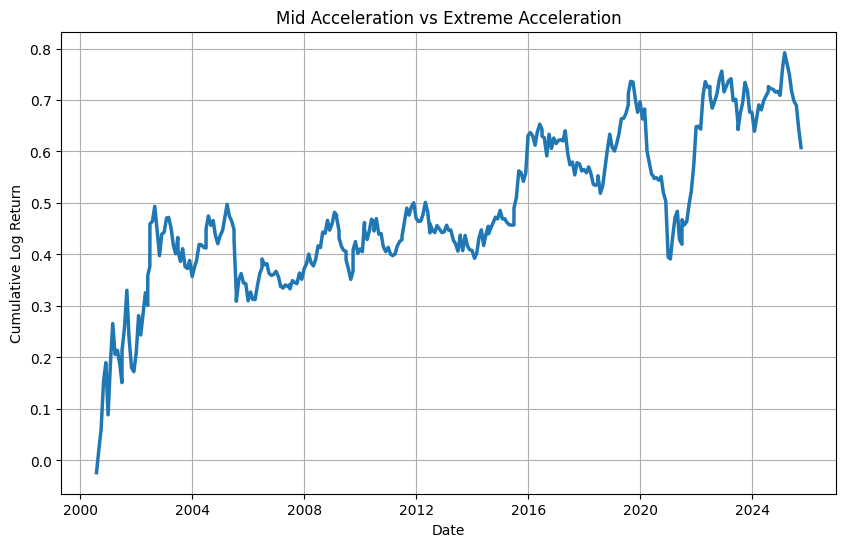

In [31]:
# mid acceleration
mid = scored.filter(pl.col("decile").is_in([4,5,6]))
extremes = scored.filter(pl.col("decile").is_in([1,10]))

mid_ret = mid.group_by("date").agg(pl.col("ret_fwd_1m").mean().alias("mid"))
ext_ret = extremes.group_by("date").agg(pl.col("ret_fwd_1m").mean().alias("ext"))

combo = mid_ret.join(ext_ret, on="date").with_columns(
    (pl.col("mid") - pl.col("ext")).alias("spread")
)

combo_plot = (
    combo
    .sort("date")
    .with_columns(
        (1 + pl.col("spread")).log().alias("log_ret")
    )
    .with_columns(
        pl.col("log_ret").cum_sum().alias("cum_log_ret")
    )
)

plt.figure(figsize=(10, 6))
plt.plot(combo_plot["date"], combo_plot["cum_log_ret"], linewidth=2.5)
plt.title("Mid Acceleration vs Extreme Acceleration")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.grid(True)
plt.show()

In [32]:
mean_spread = combo.select(pl.col("spread").mean()).item()
std_spread = combo.select(pl.col("spread").std()).item()

print("Mean spread:", mean_spread)
print("Std spread:", std_spread)
print("Sharpe:", mean_spread / std_spread * (12 ** 0.5))

Mean spread: 0.002201820762889182
Std spread: 0.028256592173389015
Sharpe: 0.2699310240302576
